In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

#### Loading the data

In [2]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') # IBM sample data available at https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

#### Checking data types, number of columns and stats

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,No,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.dtypes # to do, assign float64 type to TotalCharges column -- ok

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
len(df.columns)

21

In [9]:
df = df.drop(columns=['customerID'])

In [10]:
df.columns = df.columns.str[0].str.upper() + df.columns.str[1:]

In [11]:
df.columns = [re.sub(r'(?<!^)(?=[A-Z])', ' ', col) for col in df.columns]

In [12]:
df.rename(columns={'Streaming T V': 'Streaming TV'}, inplace=True)

In [13]:
df.describe()

,Tenure,Monthly Charges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


#### Checking for null and empty strings

In [14]:
df['Total Charges'] = df['Total Charges'].replace(' ', np.nan)

In [15]:
df.isnull().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure                0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn                 0
dtype: int64

In [16]:
df[df['Total Charges'].isnull()]

,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
df[df['Tenure'] == 0]

,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [18]:
df.dropna(inplace=True, ignore_index=True)

In [19]:
df.isna().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

In [20]:
df['Total Charges'] = df['Total Charges'].astype(float)

In [21]:
df.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure                 int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn                 object
dtype: object

### Save cleaned  data in a new file

In [22]:
#df.to_csv('cleaned_data.csv',index=False)

### Univariate Analysis

#### Numerical features histograms

In [22]:
numerical_features = [col for col in df.columns if df[col].dtypes != 'object']

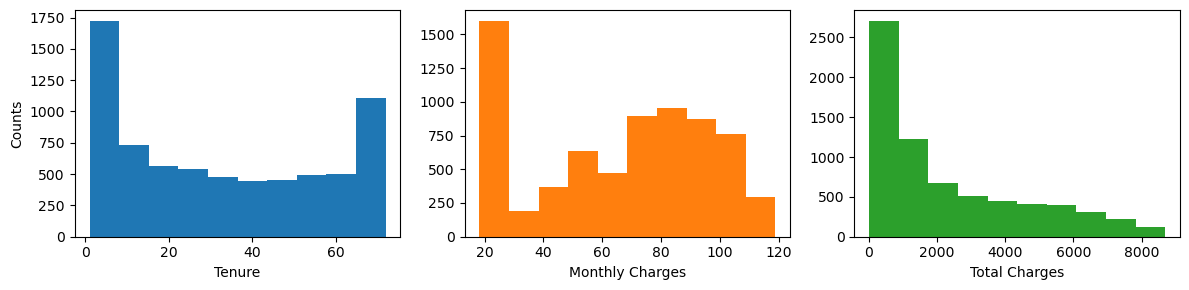

In [23]:
c = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].hist(df[numerical_features[i]], color = c[i])
    axs[i].set_xlabel(numerical_features[i])
axs[0].set_ylabel('Counts')
plt.tight_layout()

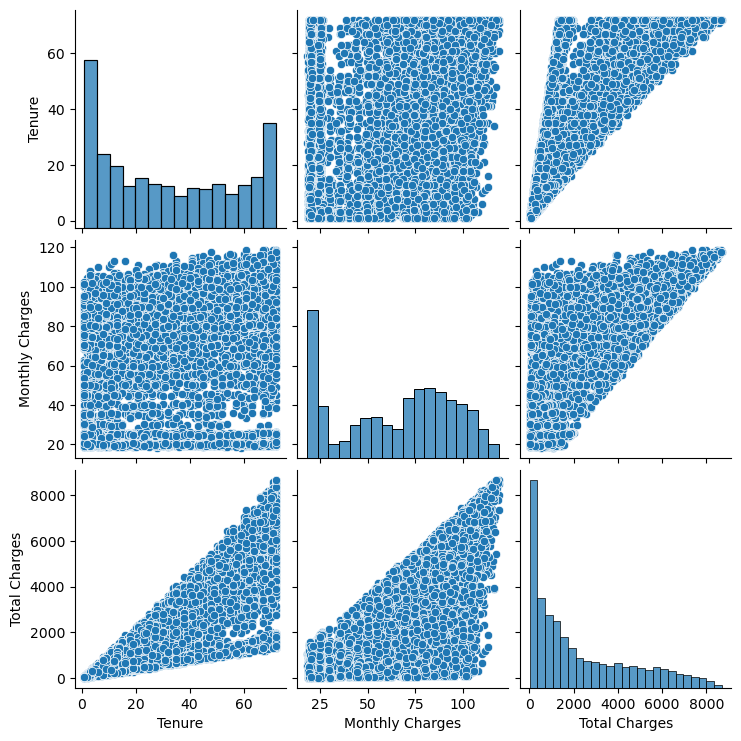

In [24]:
sns.pairplot(df[numerical_features]);

#### Categorical features pie charts

In [25]:
categorical_features = [col for col in df.columns if df[col].dtypes == 'object' and col != 'Churn']

In [26]:
for col in categorical_features:
    print(df[col].describe())

count     7032
unique       2
top       Male
freq      3549
Name: Gender, dtype: object
count     7032
unique       2
top         No
freq      5890
Name: Senior Citizen, dtype: object
count     7032
unique       2
top         No
freq      3639
Name: Partner, dtype: object
count     7032
unique       2
top         No
freq      4933
Name: Dependents, dtype: object
count     7032
unique       2
top        Yes
freq      6352
Name: Phone Service, dtype: object
count     7032
unique       3
top         No
freq      3385
Name: Multiple Lines, dtype: object
count            7032
unique              3
top       Fiber optic
freq             3096
Name: Internet Service, dtype: object
count     7032
unique       3
top         No
freq      3497
Name: Online Security, dtype: object
count     7032
unique       3
top         No
freq      3087
Name: Online Backup, dtype: object
count     7032
unique       3
top         No
freq      3094
Name: Device Protection, dtype: object
count     7032
unique      

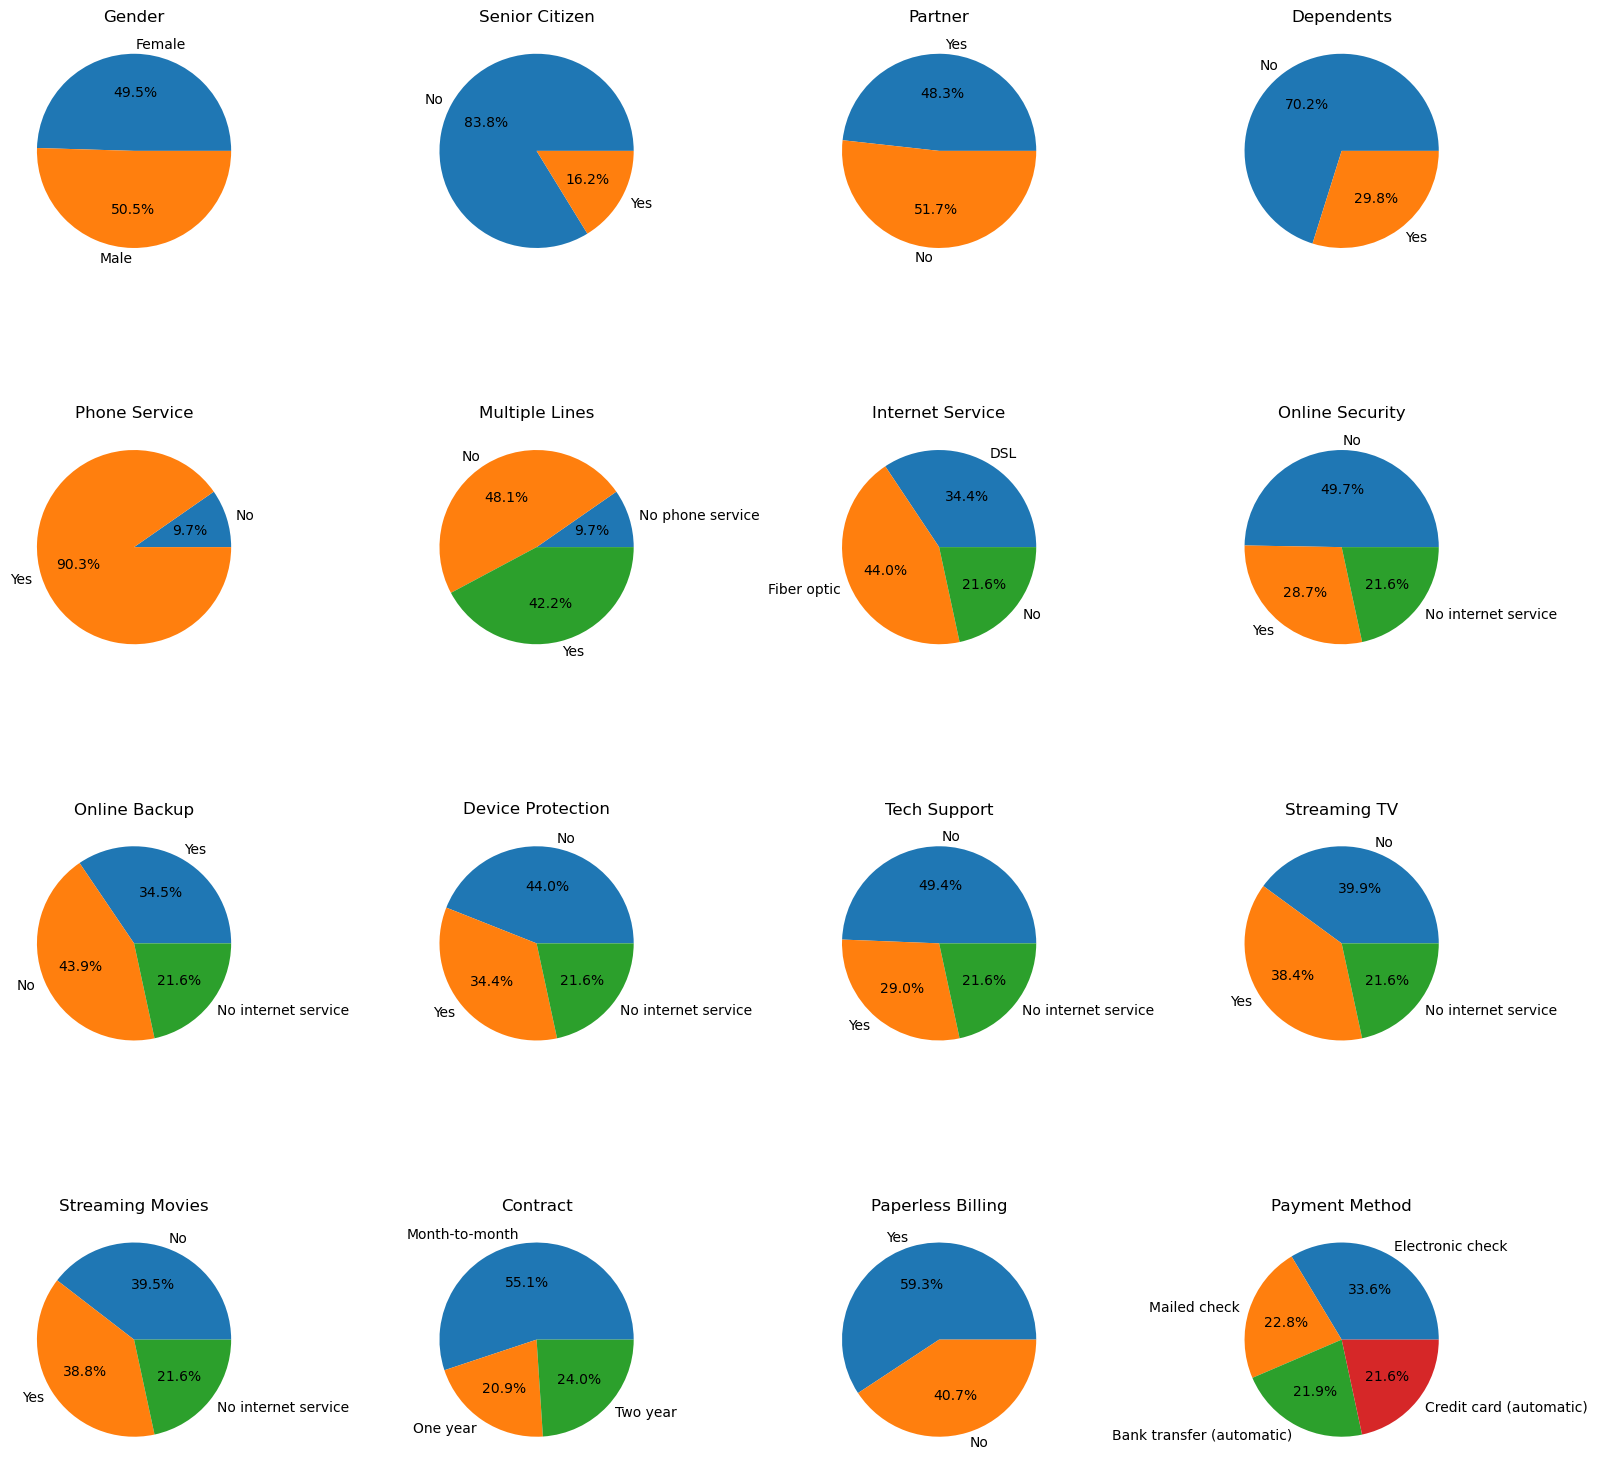

In [27]:
fig, axs = plt.subplots(4,4, figsize = (16,16))
k=0
l=0
for col in categorical_features:
    labels = df[col].unique()
    sizes = [(df[col] == labels[j]).sum() for j in range(len(labels))]

    axs[k,l].pie(sizes, labels = labels, autopct='%1.1f%%', colors = c)
    axs[k,l].set_title(col)
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1
        
plt.tight_layout()

In [109]:
df[df["Churn"]=="Yes"]["Gender"].value_counts()

Gender
Female    939
Male      930
Name: count, dtype: int64

In [110]:
df[df["Churn"]=="No"]["Gender"].value_counts()

Gender
Male      2619
Female    2544
Name: count, dtype: int64

In [99]:
pd.get_dummies(df).corr()["Churn_Yes"].sort_values()

Churn_No                                   -1.000000
Tenure                                     -0.354049
Contract_Two year                          -0.301552
Streaming Movies_No internet service       -0.227578
Streaming TV_No internet service           -0.227578
Tech Support_No internet service           -0.227578
Device Protection_No internet service      -0.227578
Online Security_No internet service        -0.227578
Internet Service_No                        -0.227578
Online Backup_No internet service          -0.227578
Total Charges                              -0.199484
Paperless Billing_No                       -0.191454
Contract_One year                          -0.178225
Online Security_Yes                        -0.171270
Tech Support_Yes                           -0.164716
Dependents_Yes                             -0.163128
Senior Citizen_No                          -0.150541
Partner_Yes                                -0.149982
Payment Method_Credit card (automatic)     -0.

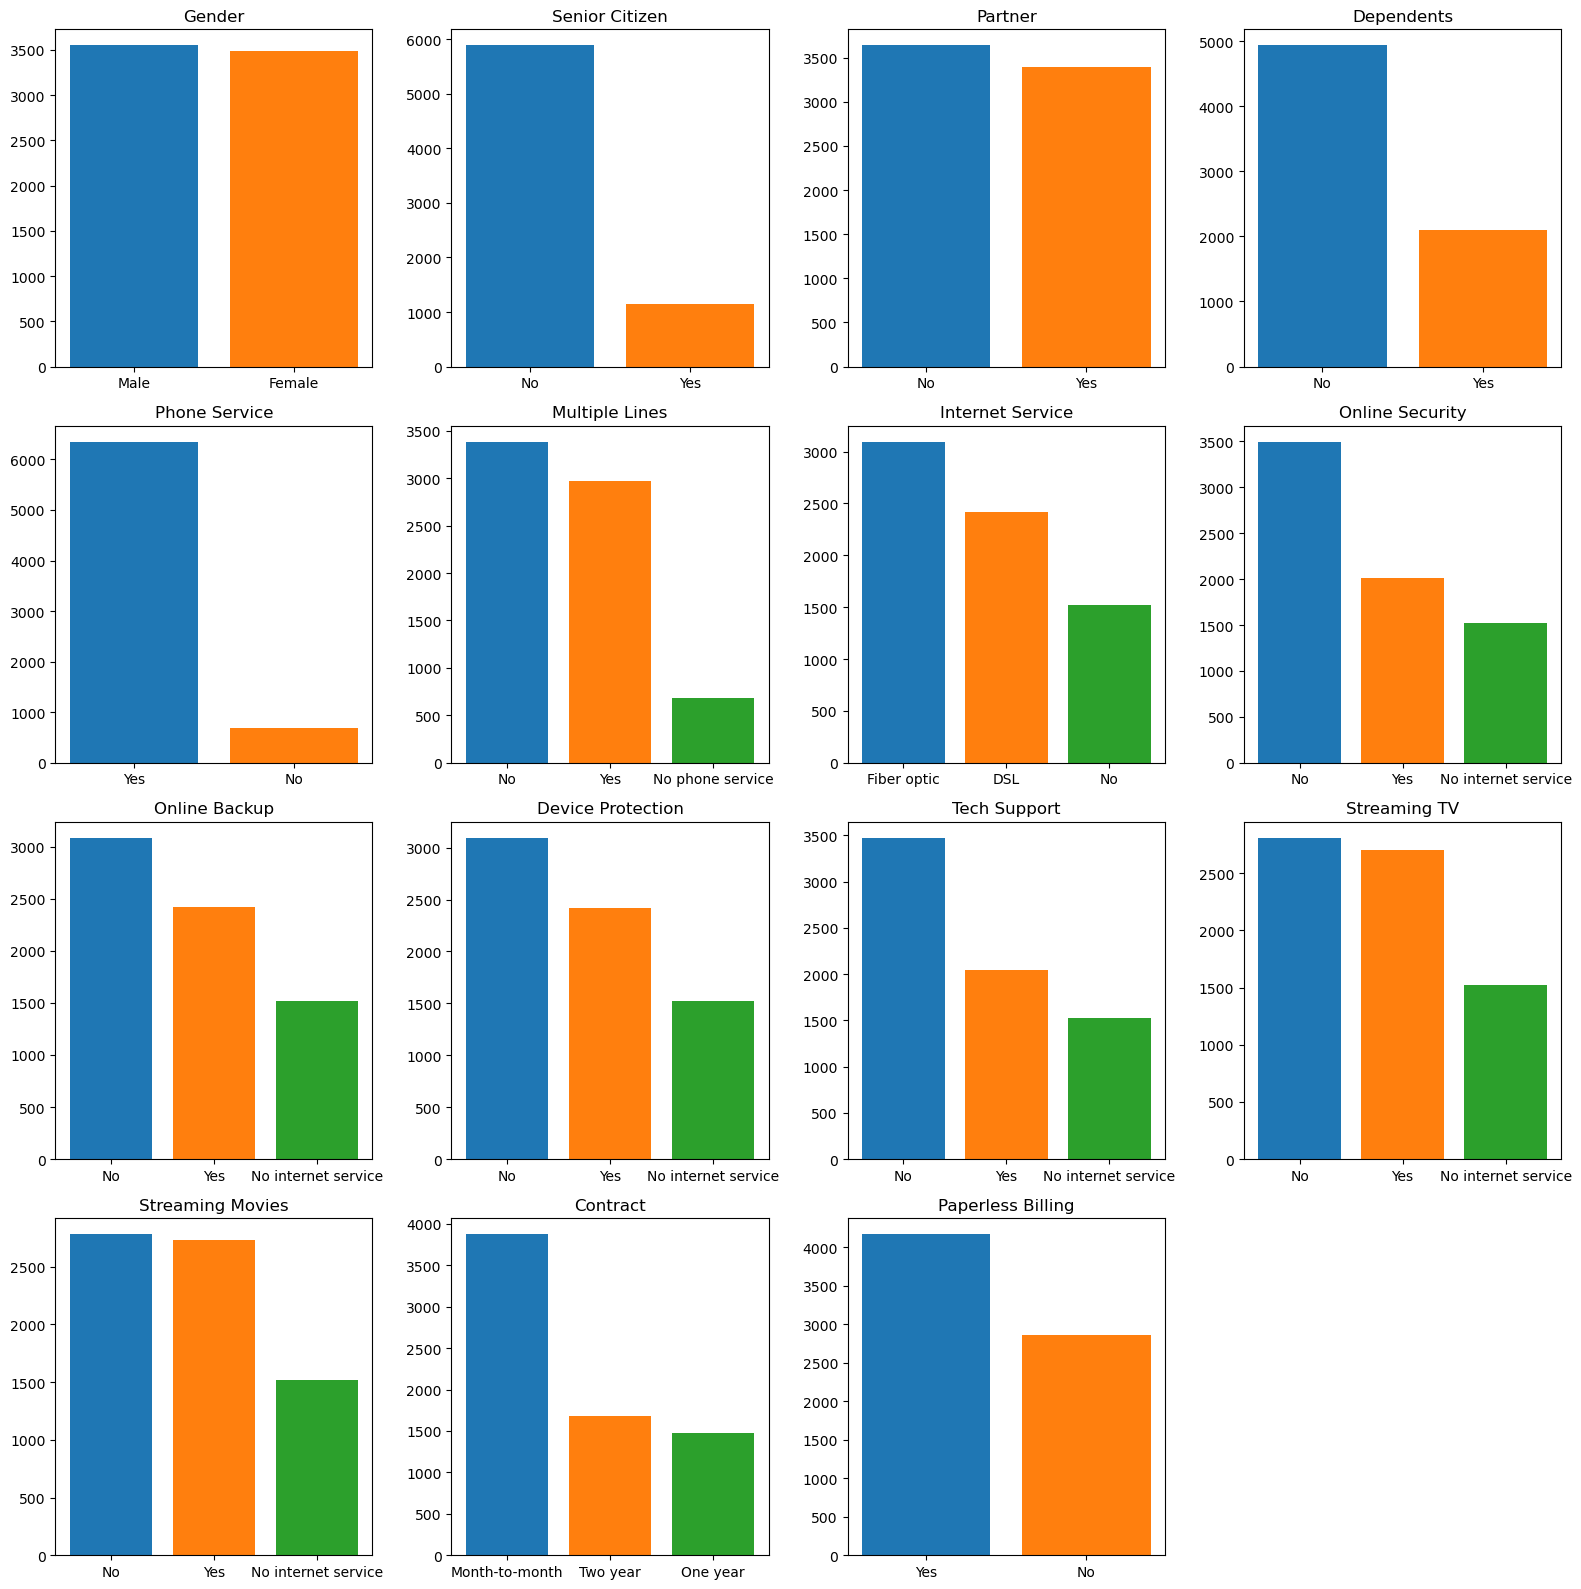

In [28]:
fig, axs = plt.subplots(4,4, figsize = (16,16))
k=0
l=0
for col in categorical_features[:-1]:
    labels = df[col].unique()
    counts = df[col].value_counts()

    axs[k,l].bar(counts.index, counts.values, color = c)
    axs[k,l].set_title(col)
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1

axs[k,l].set_axis_off()
plt.tight_layout()

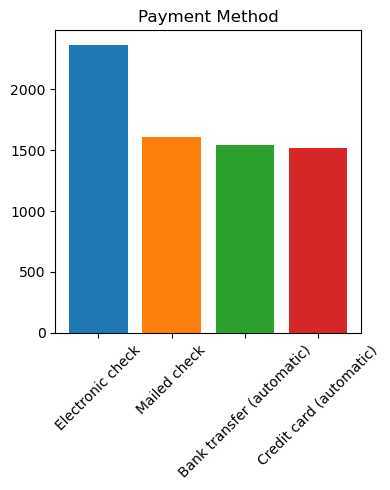

In [29]:
fig, ax = plt.subplots(1,1, figsize = (4,5))

for col in categorical_features[-1:]:
    labels = df[col].unique()
    counts = df[col].value_counts()

    ax.bar(counts.index, counts.values, color = c)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

### Univariate Numerical Features Analysis with churn

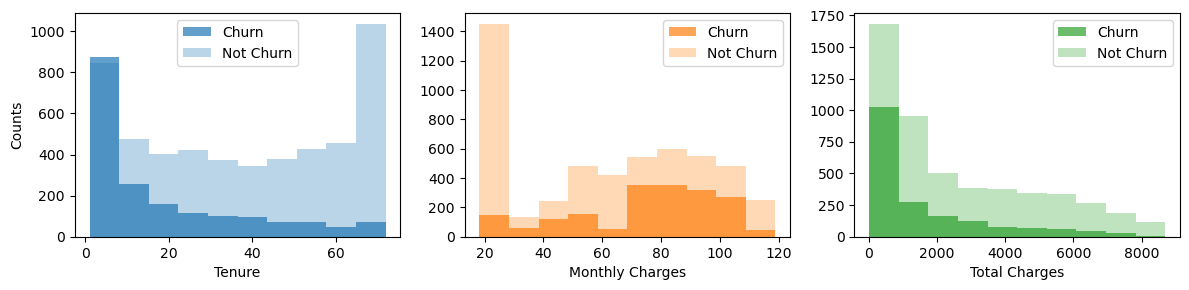

In [30]:
c = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    bins = np.histogram(np.hstack((df[df['Churn'] == 'Yes'][numerical_features[i]],df[df['Churn'] == 'No'][numerical_features[i]])), bins = 10)[1]
    axs[i].hist(df[df['Churn'] == 'Yes'][numerical_features[i]], color = c[i], alpha = 0.7, bins = bins, label = 'Churn')
    axs[i].hist(df[df['Churn'] == 'No'][numerical_features[i]], color = c[i], alpha = 0.3, bins = bins, label = 'Not Churn')
    axs[i].set_xlabel(numerical_features[i])
    axs[i].legend()
axs[0].set_ylabel('Counts')
plt.tight_layout()

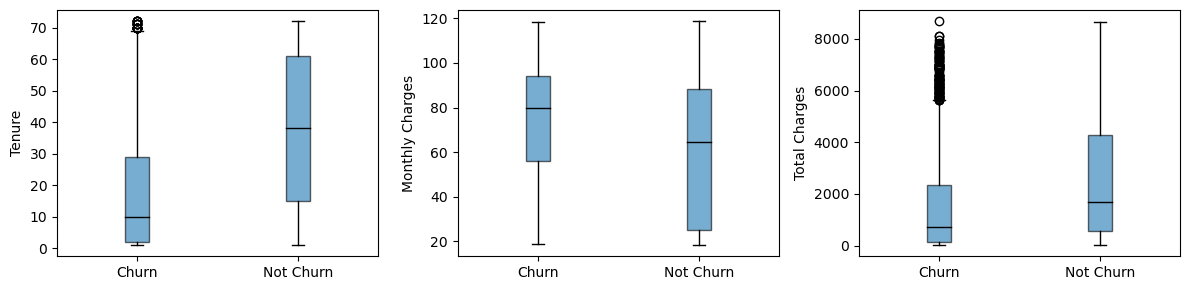

In [31]:
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].boxplot([df[df['Churn']=='Yes'][numerical_features[i]],df[df['Churn']=='No'][numerical_features[i]]],
                   patch_artist=True, labels = ['Churn', 'Not Churn'], 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
    axs[i].set_ylabel(numerical_features[i])
    
plt.tight_layout()

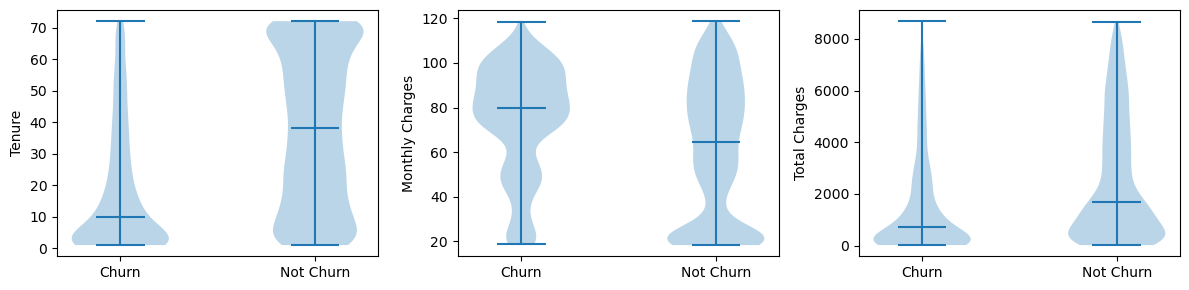

In [32]:
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].violinplot([df[df['Churn']=='Yes'][numerical_features[i]],df[df['Churn']=='No'][numerical_features[i]]],showmeans=False,showmedians=True)
    axs[i].set_ylabel(numerical_features[i])
    axs[i].set_xticks([y + 1 for y in range(2)], labels=['Churn', 'Not Churn'])
plt.tight_layout()

### Univariate Categorical Features Analysis with churn

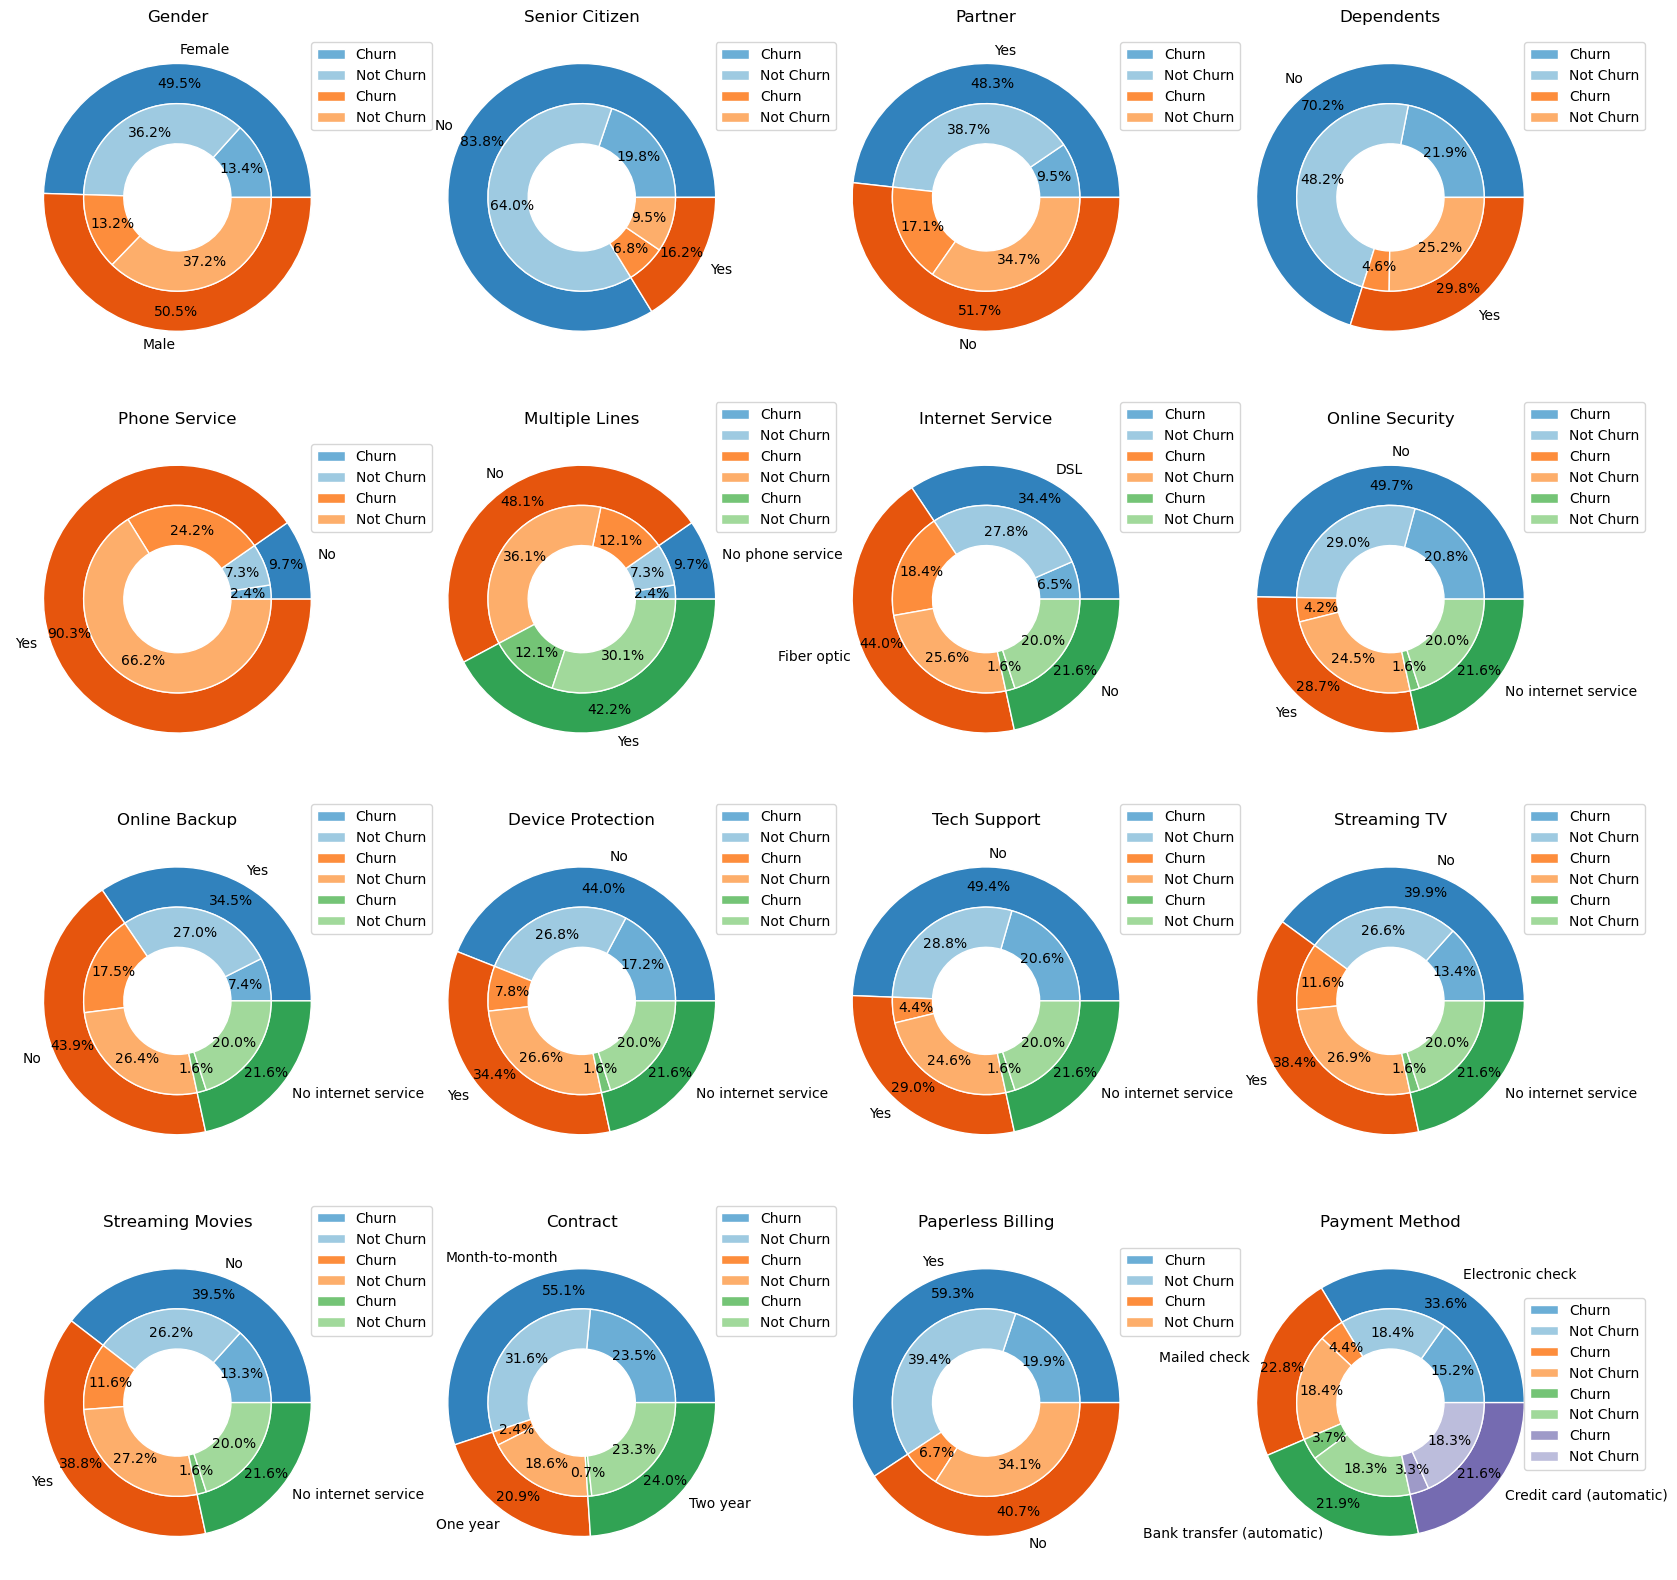

In [33]:
tab20c = plt.color_sequences["tab20c"]
outer_colors = [tab20c[i] for i in [0, 4, 8, 12]]
inner_colors = [tab20c[i] for i in [1, 2, 5, 6, 9, 10, 13, 14]]

fig, axs = plt.subplots(4,4, figsize = (20,20))
k=0
l=0

for col in categorical_features:
    width = 0.3
    group_labels = df[col].unique()
    vals = np.array([[((df[col] == group_labels[j]) & (df['Churn'] == 'Yes')).sum(), ((df[col] == group_labels[j]) & (df['Churn'] == 'No')).sum()] for j in range(len(group_labels))])

    axs[k,l].pie(vals.sum(axis=1), radius=1, colors=outer_colors,
       wedgeprops=dict(width=width, edgecolor='w'), labels = group_labels, autopct='%1.1f%%', pctdistance=0.85)
    axs[k,l].pie(vals.flatten(), radius=1-width, colors=inner_colors,
       wedgeprops=dict(width=width, edgecolor='w'), labels = ['Churn', 'Not Churn']*len(group_labels), labeldistance=None, autopct='%1.1f%%', pctdistance=0.75)

    axs[k,l].set(aspect="equal", title=col)
    handles, labels = axs[k,l].get_legend_handles_labels()
    
    if col == 'Payment Method':
        axs[k,l].legend(handles[len(group_labels):], ['Churn', 'Not Churn']*len(group_labels), loc=(0.9, 0.3)) 
    else:
        axs[k,l].legend(handles[len(group_labels):], ['Churn', 'Not Churn']*len(group_labels), loc=(0.9, 0.7))
    
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1

axs[3,3].set_axis_off()
plt.show()

### Other tests

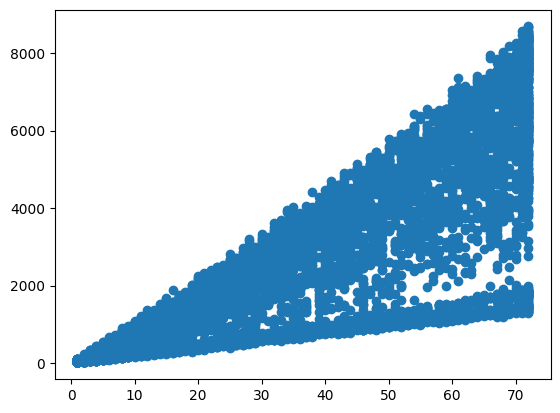

In [22]:
plt.scatter(df["Tenure"],df["Total Charges"]);

In [23]:
df[["Tenure","Monthly Charges","Total Charges"]].corr()

,Tenure,Monthly Charges,Total Charges
Tenure,1.000000,0.246862,0.825880
Monthly Charges,0.246862,1.000000,0.651065
Total Charges,0.825880,0.651065,1.000000


In [24]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
len(df[(df["Phone Service"]=="Yes") & (df["Internet Service"]!="No")])

4832

In [40]:
len(df[(df["Phone Service"]=="Yes")])

6352

In [42]:
len(df[df["Internet Service"]!="No"])

5512

In [25]:
df["Phone Service"].value_counts()

Phone Service
Yes    6352
No      680
Name: count, dtype: int64

In [29]:
6352/7032

0.9032992036405005

In [34]:
427106.1/455661.0

0.9373330173089204

In [26]:
df["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [27]:
3096+2416

5512

In [28]:
5512/7032

0.7838452787258248

In [48]:
df[(df["Partner"]=="Yes") & (df["Dependents"]=="Yes")]["Churn"].value_counts()

Churn
No     1491
Yes     249
Name: count, dtype: int64

In [49]:
249/(249+1491)

0.14310344827586208

In [27]:
249/7032

0.035409556313993173

In [53]:
df[(df["Partner"]=="Yes") & (df["Dependents"]=="Yes")].describe()

,Tenure,Monthly Charges,Total Charges
count,1740.000000,1740.000000,1740.000000
mean,41.578161,61.070805,2746.914914
std,23.622272,31.649204,2358.492234
min,1.000000,18.700000,18.800000
25%,20.000000,24.687500,761.275000
50%,45.000000,65.125000,1833.275000
75%,65.000000,88.850000,4559.975000
max,72.000000,118.750000,8672.450000


In [28]:
df[(df["Partner"]=="No") & (df["Dependents"]=="No")]["Churn"].value_counts()

Churn
No     2157
Yes    1123
Name: count, dtype: int64

In [29]:
1123/(1123+2157)

0.34237804878048783

In [30]:
1123/7032

0.15969852104664392

In [54]:
df[(df["Partner"]=="No") & (df["Dependents"]=="No")].describe()

,Tenure,Monthly Charges,Total Charges
count,3280.000000,3280.000000,3280.000000
mean,23.303354,62.983735,1610.702439
std,21.854290,28.925200,1899.021150
min,1.000000,18.250000,18.850000
25%,4.000000,36.600000,193.600000
50%,16.000000,69.700000,810.650000
75%,39.000000,86.000000,2404.325000
max,72.000000,118.650000,8547.150000


In [34]:
df[df["Internet Service"]=="Fiber optic"]["Churn"].value_counts()

Churn
No     1799
Yes    1297
Name: count, dtype: int64

In [35]:
1297/(1297+1799)

0.4189276485788114

In [37]:
(1297+1799)/7032

0.4402730375426621

In [44]:
df[(df["Internet Service"]=="Fiber optic") & (df["Tech Support"]=="No")]["Churn"].value_counts()

Churn
No     1129
Yes    1101
Name: count, dtype: int64

In [45]:
1101/(1101+1129)

0.49372197309417043

In [46]:
(1101+1129)/7032

0.3171217292377702

In [47]:
df[(df["Internet Service"]=="Fiber optic") & (df["Tech Support"]=="Yes")]["Churn"].value_counts()

Churn
No     670
Yes    196
Name: count, dtype: int64

In [48]:
196/(196+670)

0.22632794457274827

In [49]:
(196+670)/7032

0.12315130830489192

In [50]:
df_services=df[["Phone Service","Internet Service","Online Security","Online Backup","Device Protection","Tech Support","Streaming TV","Streaming Movies"]]
df_services.head()

,Phone Service,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
0,No,DSL,No,Yes,No,No,No,No
1,Yes,DSL,Yes,No,Yes,No,No,No
2,Yes,DSL,Yes,Yes,No,No,No,No
3,No,DSL,Yes,No,Yes,Yes,No,No
4,Yes,Fiber optic,No,No,No,No,No,No


In [57]:
mapping={"Yes":1, "Fiber optic":1, "DSL":1, "No":0, "No internet service":0}

In [58]:
for col in df_services.columns:
    df_services.loc[:,col]=df_services.loc[:,col].map(mapping)

In [59]:
df_services.head()

,Phone Service,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
0,0,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0
2,1,1,1,1,0,0,0,0
3,0,1,1,0,1,1,0,0
4,1,1,0,0,0,0,0,0


In [60]:
df_services.isna().sum()

Phone Service        0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
dtype: int64

In [61]:
number_of_services=df_services.sum(axis=1).to_frame()
number_of_services.columns=["Number of services"]
number_of_services.head()

,Number of services
0,2
1,4
2,4
3,4
4,2


In [64]:
df_test=pd.concat((df,number_of_services),axis=1)
df_test.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,Number of services
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2


In [80]:
df_test[df_test["Churn"]=="No"].describe(include=['O'])

,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn,Number of services
count,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,1,8
top,Male,No,Yes,No,Yes,No,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,No,1
freq,2619,4497,2724,3390,4653,2536,1957,2036,1902,1883,2026,1889,1913,2220,2768,1296,5163,1452


In [81]:
df_test[df_test["Churn"]=="No"].describe()

,Tenure,Monthly Charges,Total Charges
count,5163.00000,5163.000000,5163.000000
mean,37.65001,61.307408,2555.344141
std,24.07694,31.094557,2329.456984
min,1.00000,18.250000,18.800000
25%,15.00000,25.100000,577.825000
50%,38.00000,64.450000,1683.600000
75%,61.00000,88.475000,4264.125000
max,72.00000,118.750000,8672.450000


In [84]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [86]:
df[df["Contract"]=="Month-to-month"]["Phone Service"].value_counts()

Phone Service
Yes    3499
No      376
Name: count, dtype: int64

In [89]:
df[df["Contract"]=="Month-to-month"]["Internet Service"].value_counts()

Internet Service
Fiber optic    2128
DSL            1223
No              524
Name: count, dtype: int64

In [87]:
df[df["Contract"]=="Two year"]["Phone Service"].value_counts()

Phone Service
Yes    1526
No      159
Name: count, dtype: int64

In [90]:
df[df["Contract"]=="Two year"]["Internet Service"].value_counts()

Internet Service
No             633
DSL            623
Fiber optic    429
Name: count, dtype: int64

In [88]:
df[df["Contract"]=="One year"]["Phone Service"].value_counts()

Phone Service
Yes    1327
No      145
Name: count, dtype: int64

In [91]:
df[df["Contract"]=="One year"]["Internet Service"].value_counts()

Internet Service
DSL            570
Fiber optic    539
No             363
Name: count, dtype: int64

In [70]:
df_test[df_test["Number of services"]==1]["Phone Service"].value_counts()

Phone Service
Yes    1520
No       80
Name: count, dtype: int64

In [71]:
df_test[df_test["Number of services"]==1]["Internet Service"].value_counts()

Internet Service
No     1520
DSL      80
Name: count, dtype: int64

In [72]:
df_test[df_test["Number of services"]==2]["Phone Service"].value_counts()

Phone Service
Yes    613
No     114
Name: count, dtype: int64

In [73]:
df_test[df_test["Number of services"]==2]["Internet Service"].value_counts()

Internet Service
Fiber optic    399
DSL            328
Name: count, dtype: int64

In [119]:
df4=pd.concat((number_of_services,df[["Monthly Charges","Total Charges", "Churn"]]),axis=1)
df4.head()

,Number of services,Monthly Charges,Total Charges,Churn
0,2,29.85,29.85,No
1,4,56.95,1889.50,No
2,4,53.85,108.15,Yes
3,4,42.30,1840.75,No
4,2,70.70,151.65,Yes


In [126]:
df5=df4.groupby(by=["Number of services","Churn"]).mean().reset_index()
df5.head()

,Number of services,Churn,Monthly Charges,Total Charges
0,1,No,21.251653,692.854408
1,1,Yes,21.424662,154.524324
2,2,No,54.793892,851.449858
3,2,Yes,61.045200,421.929333
4,3,No,61.171847,1425.161901


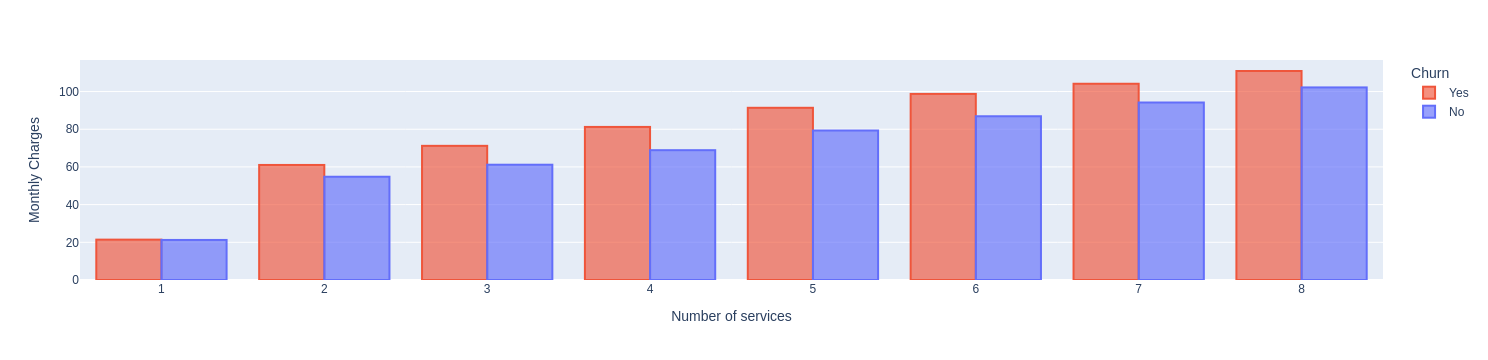

In [127]:
fig = px.bar(df5, x="Number of services", y="Monthly Charges",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

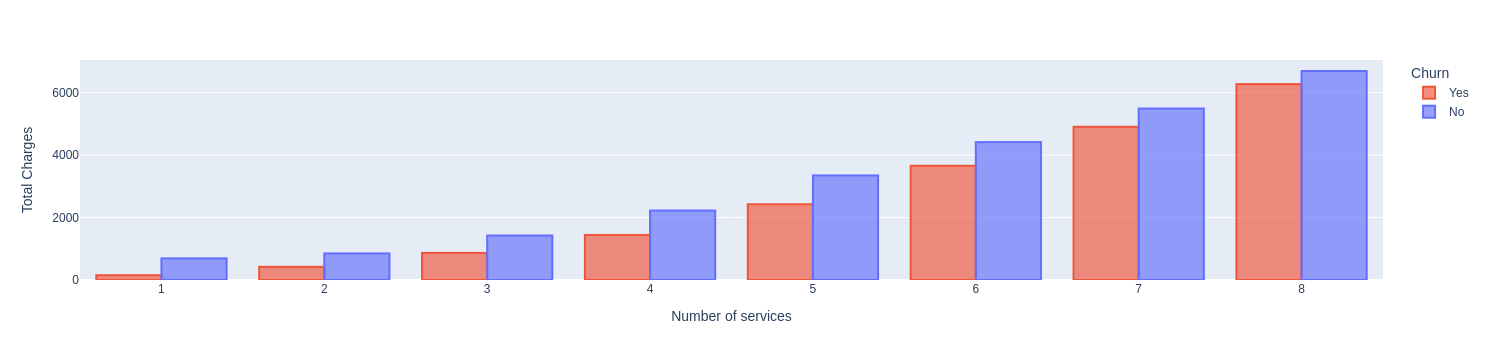

In [128]:
fig = px.bar(df5, x="Number of services", y="Total Charges",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [50]:
df_n_services=pd.concat((df[["Tenure","Monthly Charges", "Total Charges"]],number_of_services,df[["Churn"]]),axis=1)
df_n_services.head()

,Tenure,Monthly Charges,Total Charges,Number of services,Churn
0,1,29.85,29.85,2,No
1,34,56.95,1889.50,4,No
2,2,53.85,108.15,4,Yes
3,45,42.30,1840.75,4,No
4,2,70.70,151.65,2,Yes


In [51]:
services_chart=df_n_services.groupby(by=["Churn","Number of services"]).size().reset_index(name="count")
services_chart.head()

,Churn,Number of services,count
0,No,1,1452
1,No,2,352
2,No,3,563
3,No,4,680
4,No,5,771


In [52]:
total_counts={}
for val in services_chart["Number of services"].unique():
    total_counts[val]=services_chart[services_chart["Number of services"]==val]["count"].sum()

In [53]:
for i in range(len(services_chart)):
    services_chart.loc[i,"percent"]=str(round(100*services_chart.loc[i,"count"]/total_counts[services_chart["Number of services"][i]],1))+"%"

In [55]:
import plotly.express as px

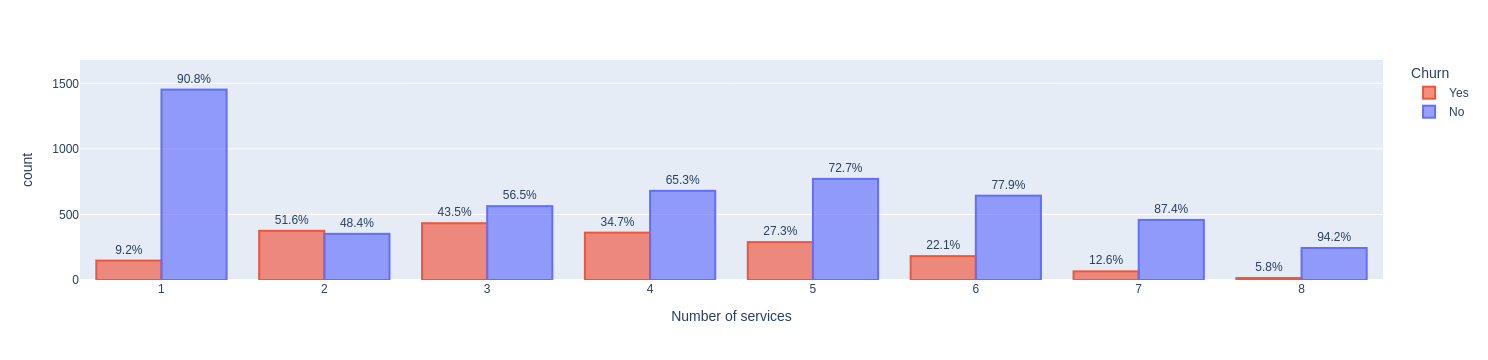

In [96]:
fig = px.bar(services_chart, x="Number of services", y="count",color="Churn", text="percent", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [54]:
df_services

,Phone Service,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
0,0,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0
2,1,1,1,1,0,0,0,0
3,0,1,1,0,1,1,0,0
4,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
7027,1,1,1,0,1,1,1,1
7028,1,1,0,1,1,0,1,1
7029,0,1,1,0,0,0,0,0
7030,1,1,0,0,0,0,0,0


In [71]:
df_services[(number_of_services["Number of services"]==1)].sum(axis=0)

Phone Service        1520
Internet Service       80
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
dtype: object

In [66]:
total_monthly_charges=df["Monthly Charges"].sum()
total_monthly_charges

455661.0

In [67]:
lost_monthly_charges=df[df["Churn"]=="Yes"]["Monthly Charges"].sum()
lost_monthly_charges

139130.85

In [68]:
lost_monthly_charges/total_monthly_charges

0.30533850823309433

In [64]:
# imediate 30% lost revenue

In [73]:
monthly_charges_median=df["Monthly Charges"].median()
monthly_charges_median

70.35

In [71]:
len(df)

7032

In [ ]:
# Let's make a naive assumption, our 

In [74]:
lost_monthly_charges/monthly_charges_median

1977.6950959488274

In [ ]:
# attract at least 1988 customer in the next month to account for this variation

In [77]:
(lost_monthly_charges/1869)*(0.7*1869)

97391.59499999999

In [78]:
97391.59499999999/total_monthly_charges

0.213736955763166

In [84]:
df_avg_charges=pd.concat((df["Total Charges"]/df["Tenure"],df["Churn"]),axis=1)
df_avg_charges.columns=["Avg charges","Churn"]
df_avg_charges.head()

,Avg charges,Churn
0,29.850000,No
1,55.573529,No
2,54.075000,Yes
3,40.905556,No
4,75.825000,Yes


In [86]:
df_avg_charges

,Avg charges,Churn
0,29.850000,No
1,55.573529,No
2,54.075000,Yes
3,40.905556,No
4,75.825000,Yes
...,...,...
7027,82.937500,No
7028,102.262500,No
7029,31.495455,No
7030,76.650000,Yes


In [94]:
import plotly.io as pio
pio.templates['plotly'].layout['autosize'] = False

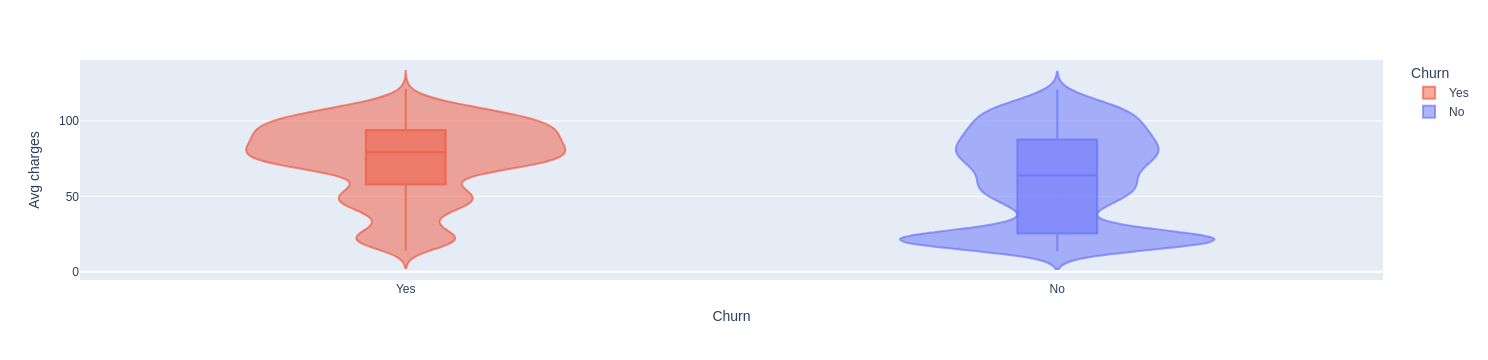

In [95]:
fig = px.violin(df_avg_charges, x="Churn", y="Avg charges",box=True,color="Churn", category_orders={"Churn":["Yes","No"]})
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

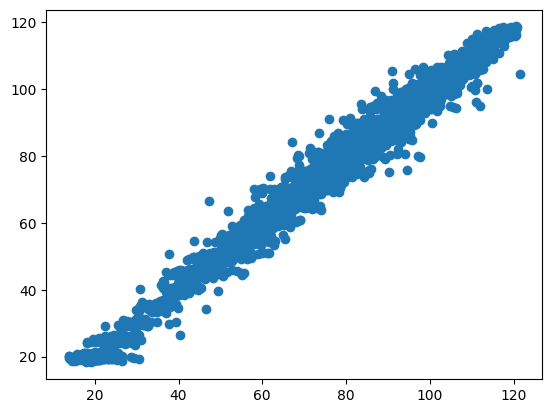

In [100]:
plt.scatter(df_avg_charges["Avg charges"],df["Monthly Charges"])

In [106]:
df3=pd.concat((df_avg_charges["Avg charges"],df["Monthly Charges"],df["Churn"]),axis=1)
df3.head()

,Avg charges,Monthly Charges,Churn
0,29.850000,29.85,No
1,55.573529,56.95,No
2,54.075000,53.85,Yes
3,40.905556,42.30,No
4,75.825000,70.70,Yes


In [108]:
df3_yes=df3[df3["Churn"]=="Yes"]
df3_no=df3[df3["Churn"]=="No"]

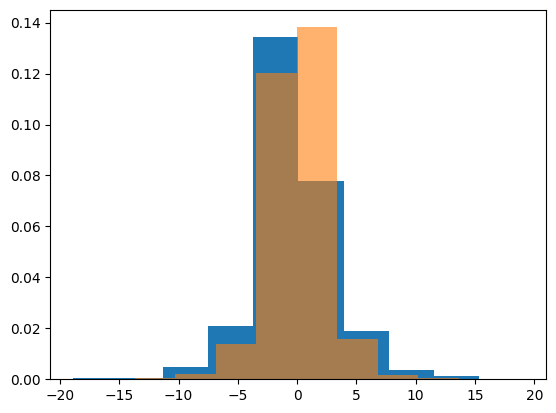

In [112]:
plt.hist(df3_yes["Monthly Charges"]-df3_yes["Avg charges"],density=True)
plt.hist(df3_no["Monthly Charges"]-df3_no["Avg charges"],alpha=0.6,density=True);

In [113]:
np.mean(df3_yes["Avg charges"]-df3_yes["Monthly Charges"])

-0.0081779188098047

In [114]:
3*np.std(df3_yes["Avg charges"]-df3_yes["Monthly Charges"])

9.97954967448848

In [115]:
np.mean(df3_no["Avg charges"]-df3_no["Monthly Charges"])

0.004615708196151506

In [116]:
3*np.std(df3_no["Avg charges"]-df3_no["Monthly Charges"])

6.9161606146986045

### Other tests

#### Boxplot per Categorical Feature

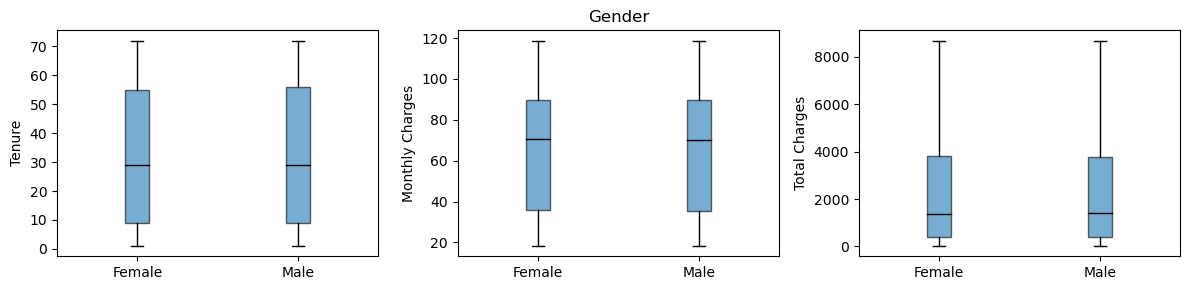

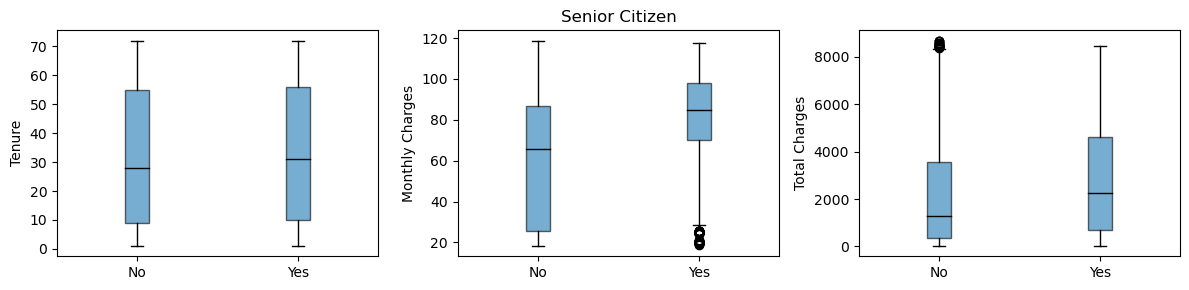

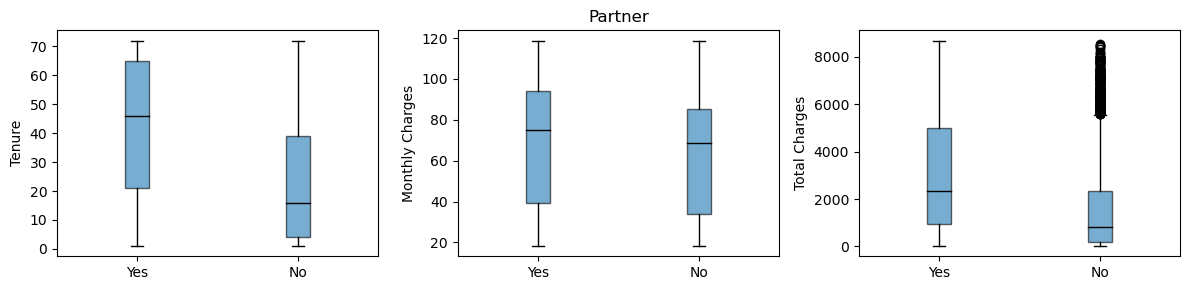

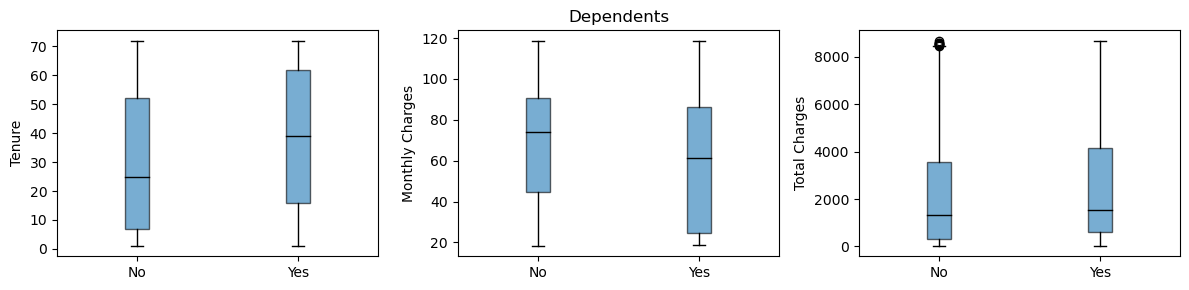

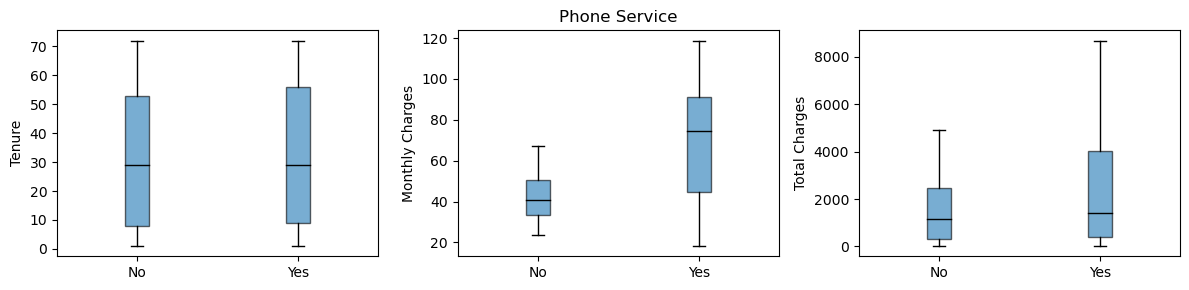

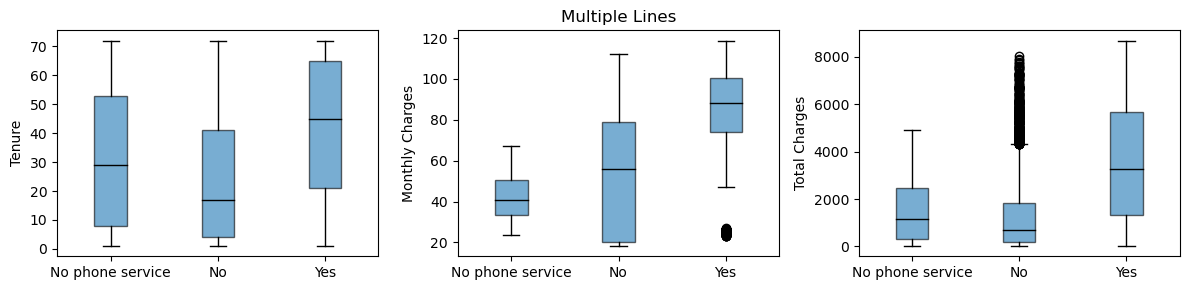

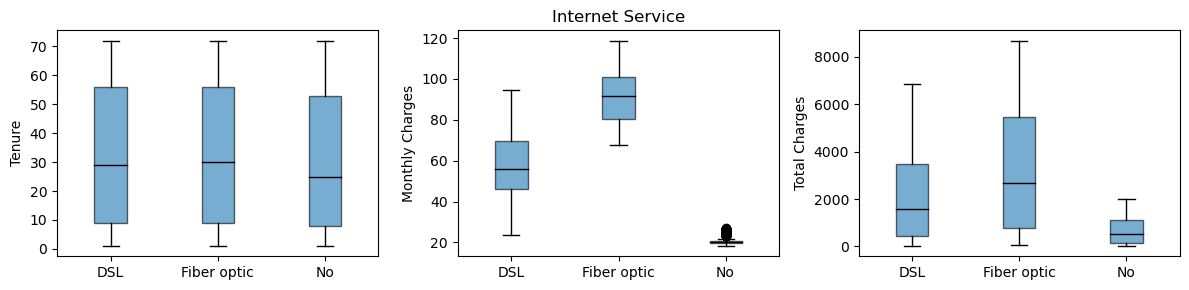

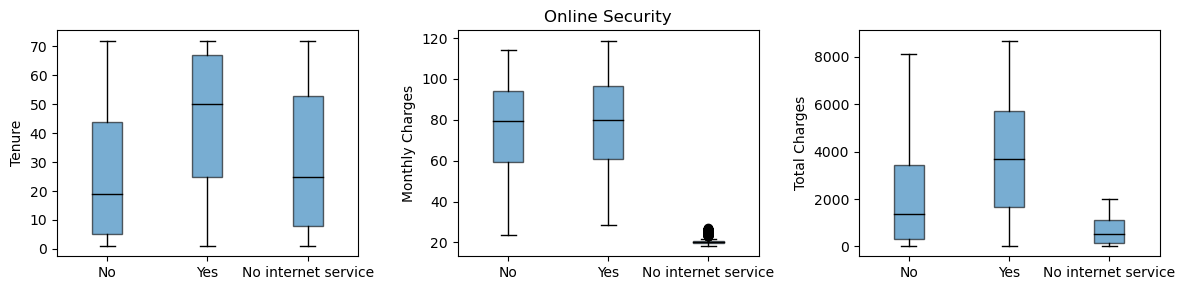

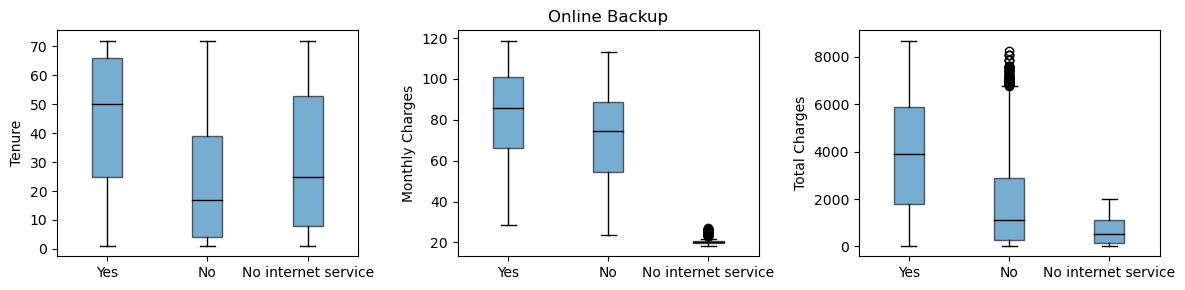

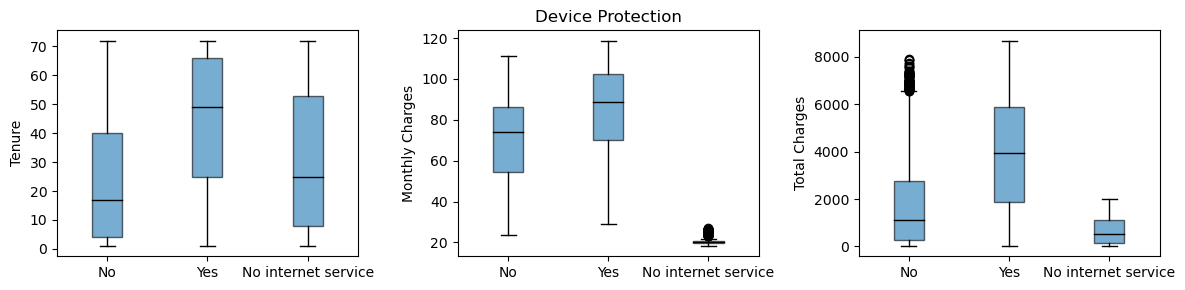

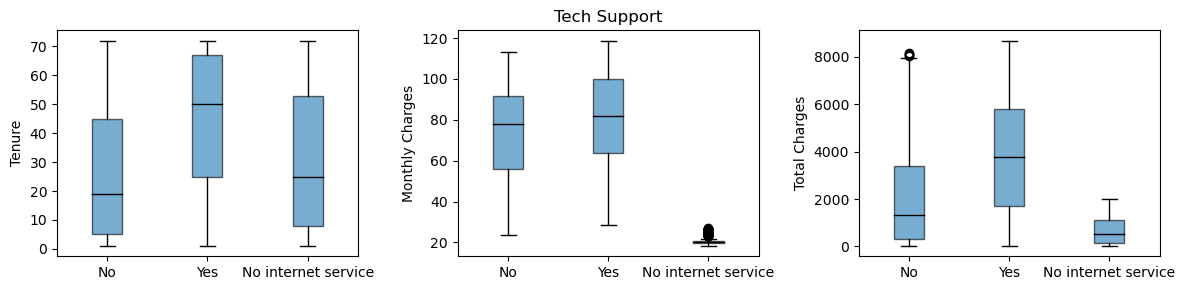

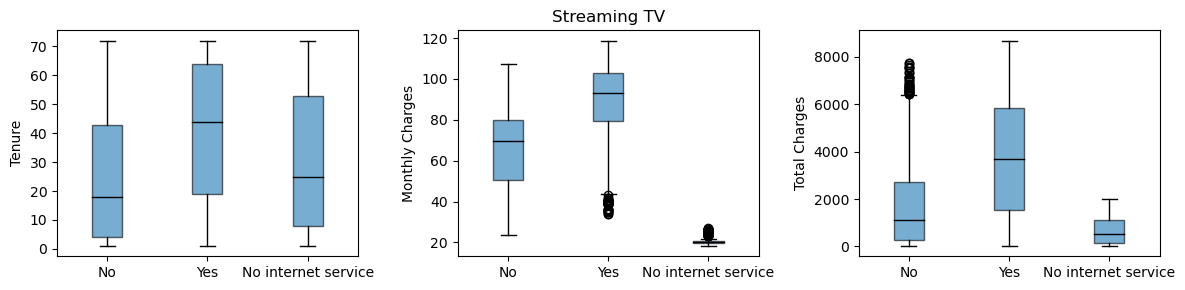

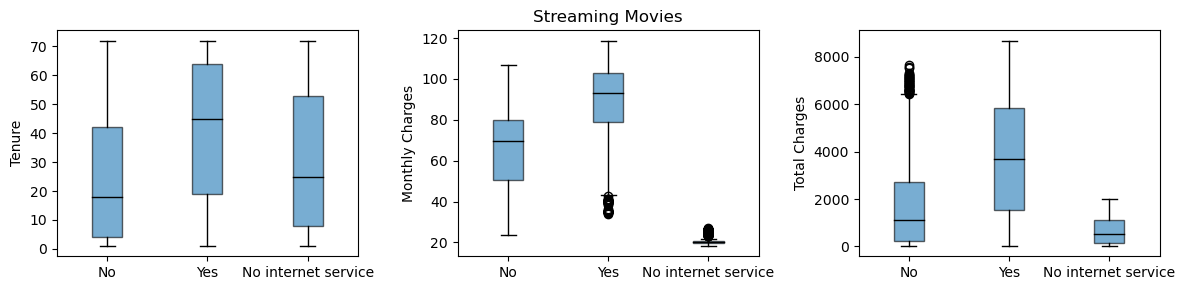

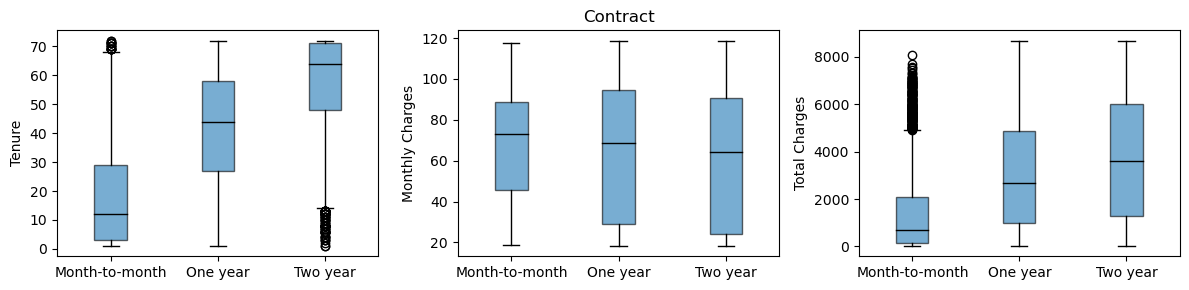

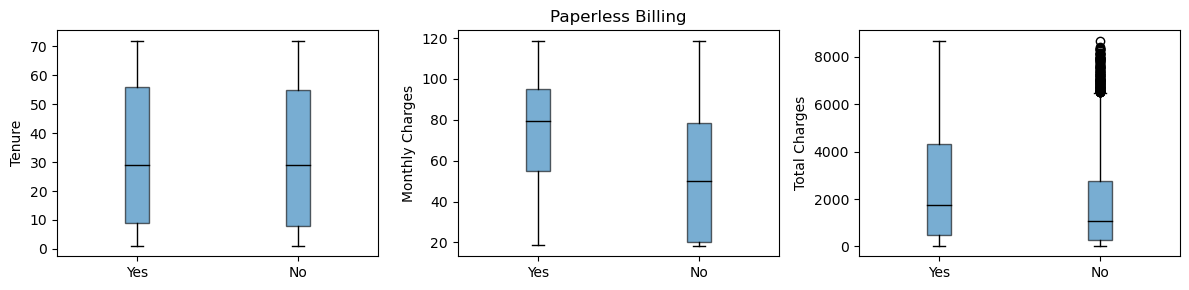

In [34]:
for col in categorical_features[:-1]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
    for i in range(len(numerical_features)):
        axs[i].boxplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                   patch_artist=True, labels = cat_values, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
        axs[i].set_ylabel(numerical_features[i])
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

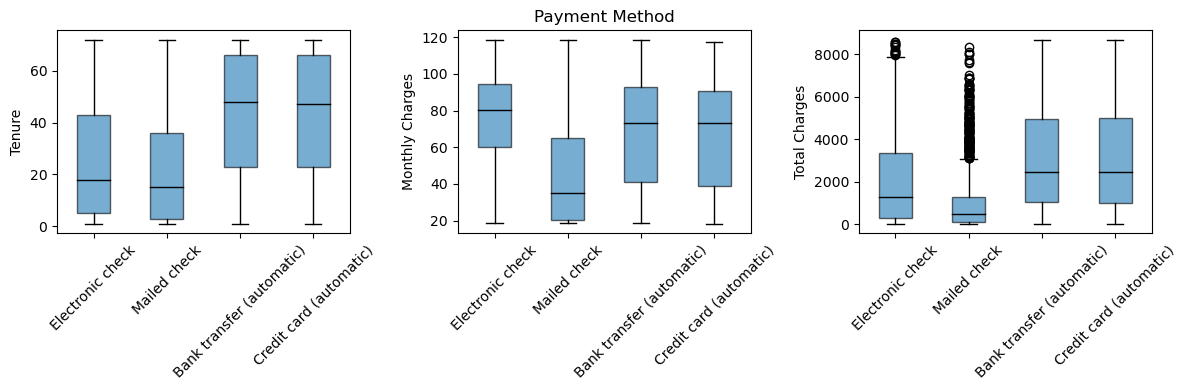

In [35]:
for col in categorical_features[-1:]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,4))
    for i in range(len(numerical_features)):
        axs[i].boxplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                   patch_artist=True, labels = cat_values, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
        axs[i].set_ylabel(numerical_features[i])
        if col == 'Payment Method':
            axs[i].tick_params(axis='x', rotation=45)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

#### Violinplot per Categorical Feature

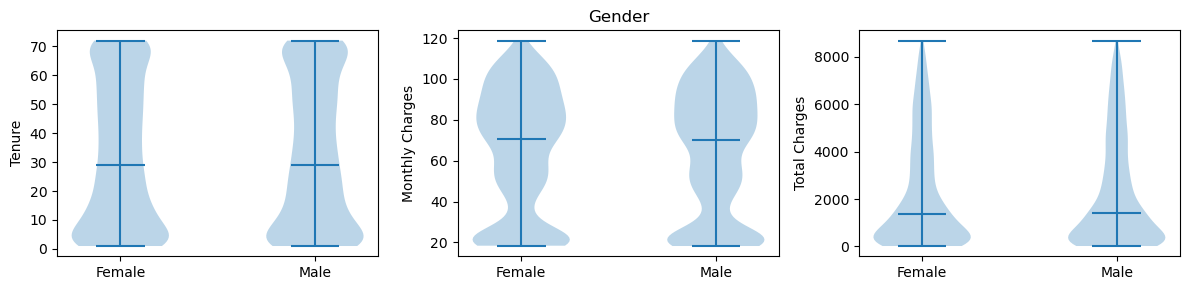

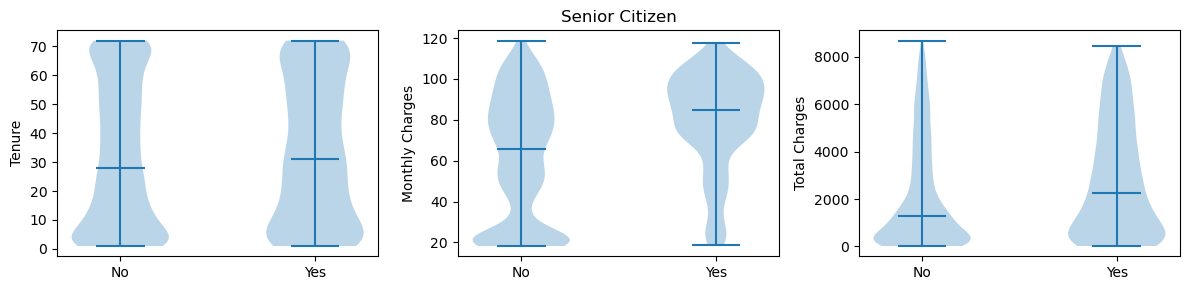

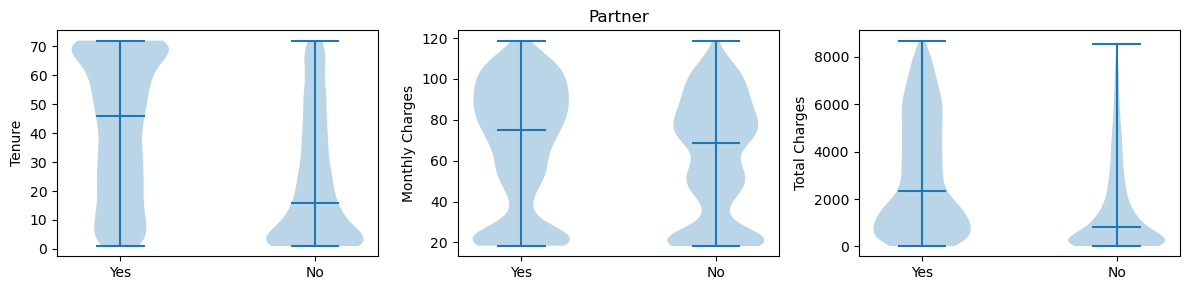

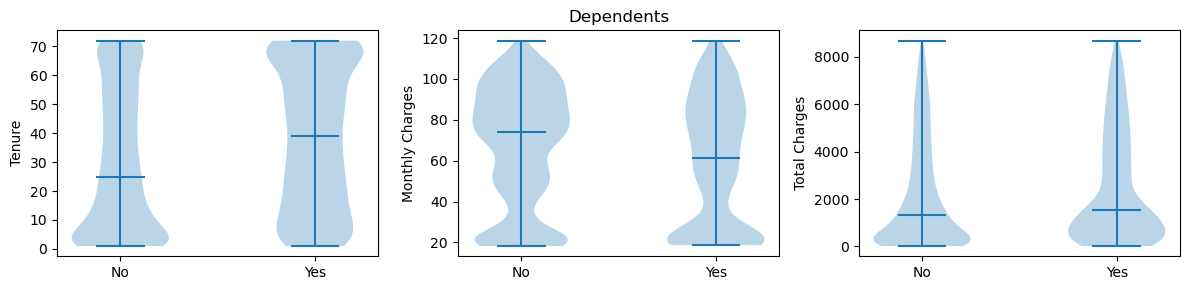

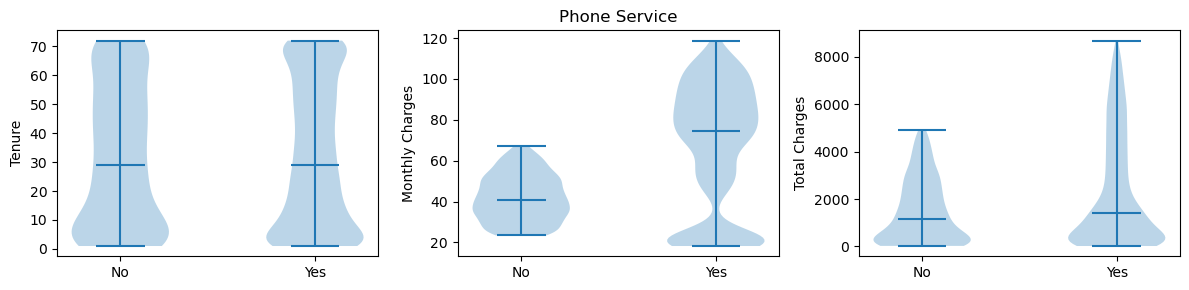

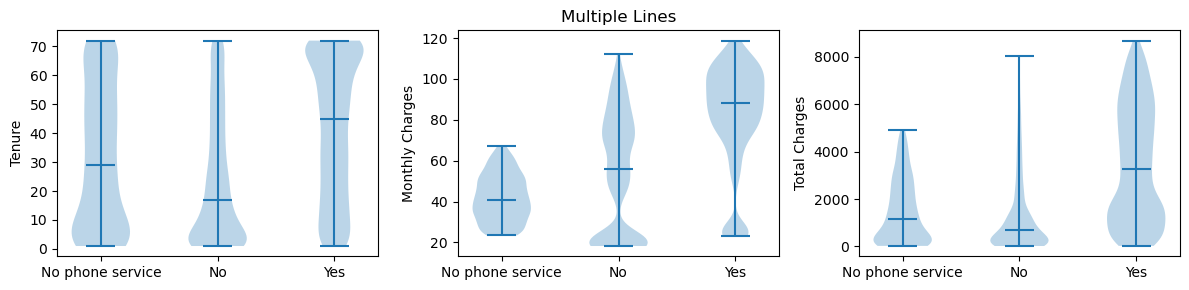

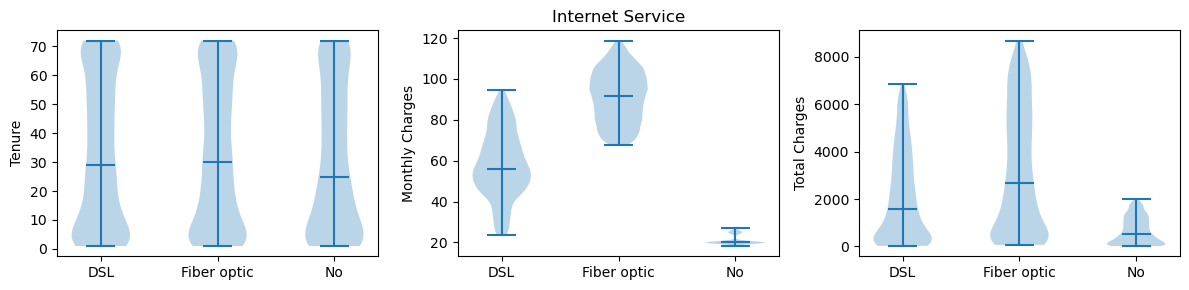

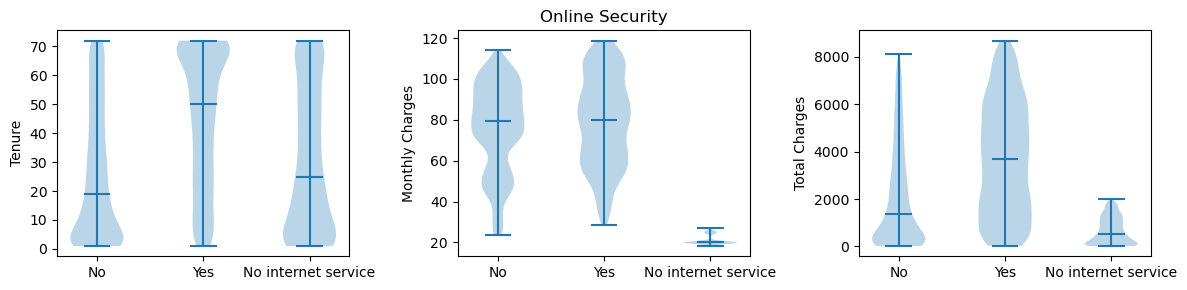

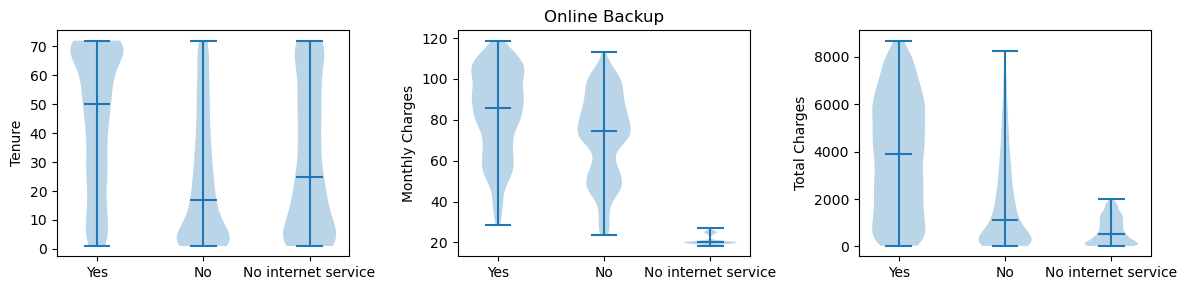

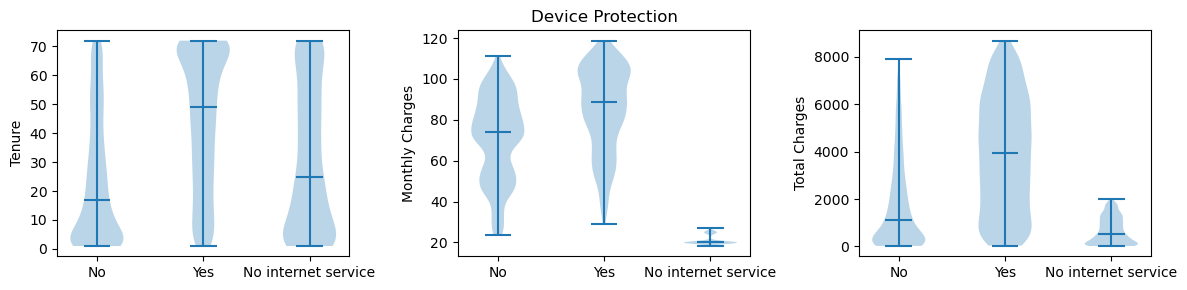

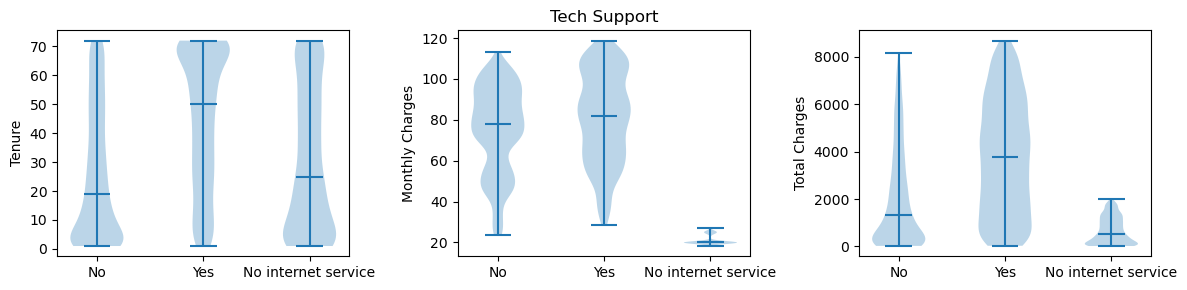

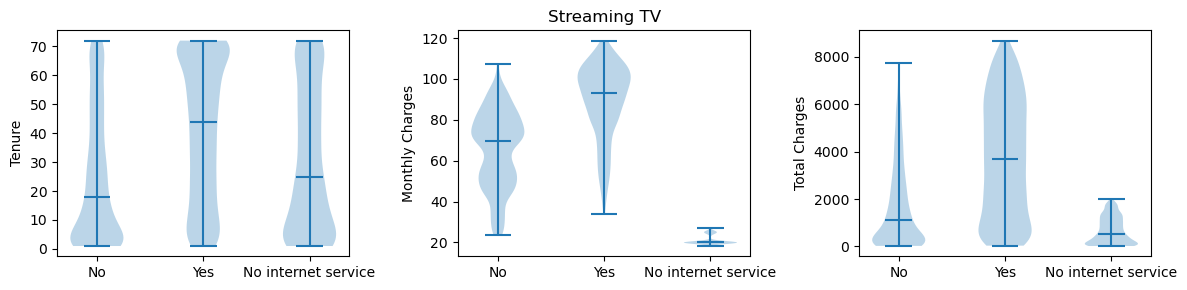

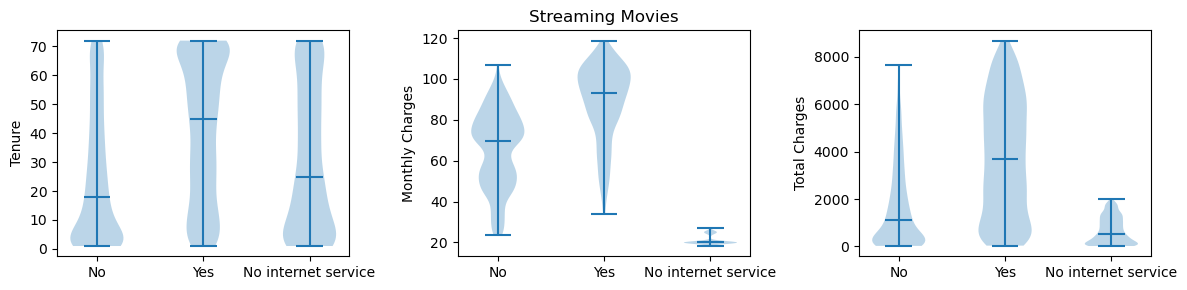

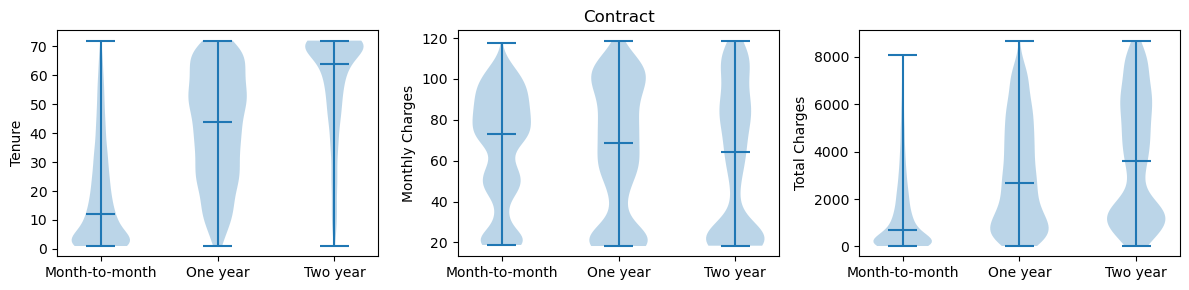

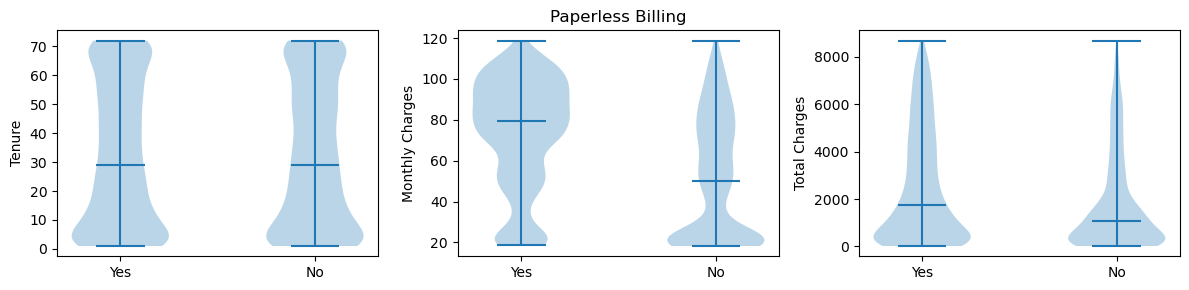

In [36]:
for col in categorical_features[:-1]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
    for i in range(len(numerical_features)):
        axs[i].violinplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                  showmeans=False,showmedians=True)
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],
                  labels=cat_values)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

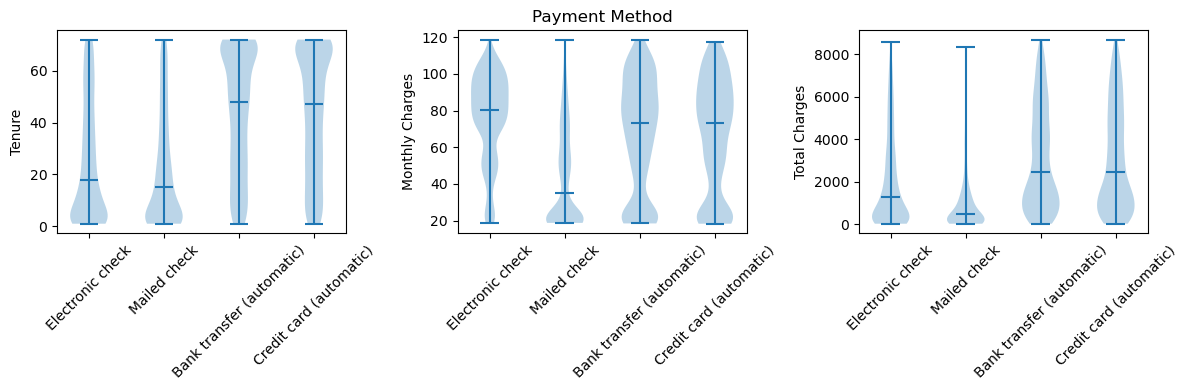

In [37]:
for col in categorical_features[-1:]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,4))
    for i in range(len(numerical_features)):
        axs[i].violinplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                  showmeans=False,showmedians=True)
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],
                  labels=cat_values)
        if col == 'Payment Method':
            axs[i].tick_params(axis='x', rotation=45)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()